<a href="https://colab.research.google.com/github/GabrielaRguezCampos/other/blob/main/Numbers_Classifier_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.83      1.00      0.90        19
           1       0.73      0.95      0.83        20
           2       0.90      0.86      0.88        22
           3       0.96      0.88      0.92        26
           4       0.71      1.00      0.83        15
           5       0.94      0.94      0.94        17
           6       1.00      0.87      0.93        23
           7       0.90      0.75      0.82        24
           8       0.92      0.92      0.92        13
           9       1.00      0.71      0.83        21

    accuracy                           0.88       200
   macro avg       0.89      0.89      0.88       200
weighted avg       0.90      0.88      0.88       200



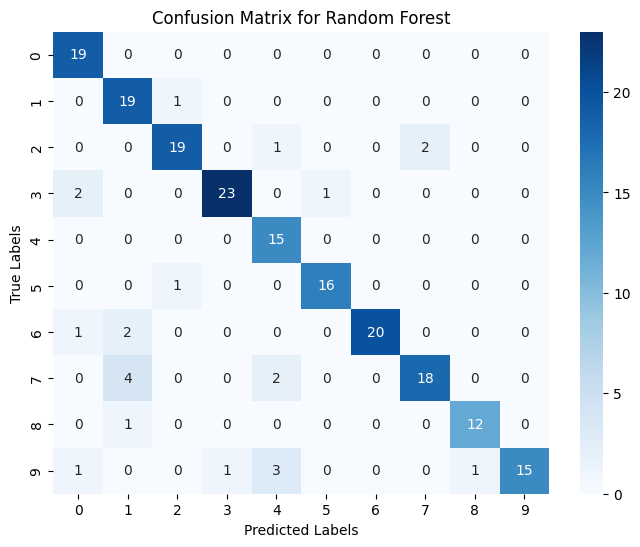

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Load MNIST dataset
mnist = fetch_openml('mnist_784')
X = mnist.data / 255.0  # Normalize the data
y = mnist.target.astype(int)  # Use int instead of np.int

# Use a subset of the data (first 1,000 samples)
X_subset = X[:1000]
y_subset = y[:1000]

# Split the subset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_subset, y_subset, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# Evaluate Random Forest model
print("Random Forest Performance:")
print(classification_report(y_test, rf_predictions))

# Confusion matrix for Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, rf_predictions), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Random Forest")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
